# Generating CDD-CESM Segmentation Masks (Google Colab)

This notebook creates a **binary mask (0/255)** for every CDD-CESM mammogram from the radiologists' hand-drawn ROI file,
and merges it with the labels in the annotation Excel file.

**Important:** `Radiology-manual-annotations.xlsx` contains only text (labels, BI-RADS, findings) and **no lesion coordinates**.
The ROI coordinates are in a separate TCIA file: **`Radiology_hand_drawn_segmentations_v2.csv`** (VGG Image Annotator/VIA format, ~1 MB).
Download it from the collection page: https://www.cancerimagingarchive.net/collection/cdd-cesm/

### Folder structure in Google Drive
```
MyDrive/CDD-CESM/
├── DATAASLI/                                   # 1003 low-energy (DM) images (.jpg)
├── Radiology_hand_drawn_segmentations_v2.csv   # ROIs from TCIA  (REQUIRED)
├── Radiology-manual-annotations.xlsx           # Excel annotations
└── Output Testing Mask/                        # (optional) previous masks, for comparison
```
Adjust the paths in the **Configuration** cell if your folder structure differs, then run **Runtime → Run all**.

### Output (`masks_generated/`)
- `masks/{Image_name}_mask.png` — binary mask, **exactly the same size** as the original image
- `master_table.csv` — combined table of image + mask + label + BI-RADS + density + quality flags
- `qc_overlays/` — sample overlays of mask contours on the images for visual inspection
- `compare_old_masks.csv` — Dice of new vs. previous masks (if the previous-mask folder is set)
- `masks_generated.zip` — all outputs in a single file

### Data source & license
CDD-CESM (Khaled et al., *Scientific Data* 9:122, 2022; https://doi.org/10.1038/s41597-022-01238-0), distributed by TCIA under CC BY 4.0.
Images and annotation files are **not** included in this repository — download them from TCIA and place them as shown above.
This notebook is part of the DMSA-KANet reproducibility package (step 1: mask generation).

## 1. Configuration

In [1]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ====== EDIT TO MATCH YOUR FILE LOCATIONS ======
BASE         = os.environ.get('CDD_BASE', '/content/drive/MyDrive/CDD-CESM')
IMG_DIR      = os.environ.get('CDD_IMG_DIR',  os.path.join(BASE, 'DATAASLI'))
SEG_CSV      = os.environ.get('CDD_SEG_CSV',  os.path.join(BASE, 'Radiology_hand_drawn_segmentations_v2.csv'))
EXCEL        = os.environ.get('CDD_EXCEL',    os.path.join(BASE, 'Radiology-manual-annotations.xlsx'))
OUT_DIR      = os.environ.get('CDD_OUT_DIR',  os.path.join(BASE, 'masks_generated'))
OLD_MASK_DIR = os.environ.get('CDD_OLD_MASK', os.path.join(BASE, 'Output Testing Mask'))  # set to None if unavailable

MODALITY              = 'DM'    # 'DM' (low-energy), 'CESM', or 'ALL' — match the images you have
MAKE_EMPTY_FOR_NORMAL = True    # write an empty (black) mask for images labelled Normal
RESPECT_THETA         = True    # rotate ellipses by the VIA theta angle (the official TCIA script ignores it)
POINT_RADIUS          = 25      # radius (px) for 'point' annotations (same as the official script)
POLYLINE_MODE         = 'polygon'  # 'polygon' (closed & filled), 'line' (thick line), or 'skip'
POLYLINE_THICKNESS    = 10
N_QC_SAMPLES          = 24      # number of QC overlays to save/display
SEED                  = 42
# ===============================================

for p, name in [(IMG_DIR, 'IMG_DIR'), (SEG_CSV, 'SEG_CSV'), (EXCEL, 'EXCEL')]:
    print(f"{'OK ' if os.path.exists(p) else 'MISSING'}  {name}: {p}")
assert os.path.exists(SEG_CSV), 'TCIA ROI CSV not found — download it first (see instructions above).'

Mounted at /content/drive
OK   IMG_DIR: /content/drive/MyDrive/CDD-CESM/DATAASLI
OK   SEG_CSV: /content/drive/MyDrive/CDD-CESM/Radiology_hand_drawn_segmentations_v2.csv
OK   EXCEL: /content/drive/MyDrive/CDD-CESM/Radiology-manual-annotations.xlsx


## 2. Import libraries

In [2]:
import json, re, glob, shutil, random
import numpy as np, pandas as pd, cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

os.makedirs(os.path.join(OUT_DIR, 'masks'), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'qc_overlays'), exist_ok=True)
random.seed(SEED); np.random.seed(SEED)

def norm_name(s):
    '''Normalize an image name: strip whitespace, extension, and directory.'''
    s = os.path.basename(str(s).strip())
    return re.sub(r'\.(jpe?g|png|tiff?|dcm)$', '', s, flags=re.I).strip()

## 3. Read the Excel annotations (one label per image)

In [3]:
ann = pd.read_excel(EXCEL, sheet_name='all')
ann.columns = [c.strip() for c in ann.columns]
ann = ann.rename(columns={'Pathology Classification/ Follow up': 'Label',
                          'Breast density (ACR)': 'ACR'})
ann['Image_name'] = ann['Image_name'].map(norm_name)
for c in ['Side', 'Type', 'View', 'Label', 'ACR']:
    ann[c] = ann[c].astype(str).str.strip()
# BI-RADS may hold several values for multiple lesions, e.g. '4$2' -> take the maximum
ann['BIRADS_raw'] = ann['BIRADS'].astype(str).str.strip()
ann['BIRADS_max'] = ann['BIRADS_raw'].map(lambda v: max(int(t) for t in re.findall(r'\d+', v)))

if MODALITY != 'ALL':
    ann = ann[ann['Type'] == MODALITY].reset_index(drop=True)
print('Excel rows used:', len(ann), '| patients:', ann.Patient_ID.nunique())
print(ann['Label'].value_counts().to_string())

Excel rows used: 1003 | patients: 326
Label
Normal       341
Malignant    331
Benign       331


## 4. Read the ROI file (VIA CSV) and match it to the images in the folder

In [4]:
seg = pd.read_csv(SEG_CSV)
seg.columns = [c.strip() for c in seg.columns]
fn_col = '#filename' if '#filename' in seg.columns else 'filename'
seg['Image_name'] = seg[fn_col].map(norm_name)
seg['region_shape_attributes'] = seg['region_shape_attributes'].fillna('{}').astype(str)

def shape_name(s):
    try:    return json.loads(s).get('name', 'empty')
    except Exception: return 'invalid'
seg['shape'] = seg['region_shape_attributes'].map(shape_name)
print('CSV rows:', len(seg), '| unique images:', seg.Image_name.nunique())
print('ROI shape types:'); print(seg['shape'].value_counts().to_string())

# index of image files in the folder (name without extension -> path)
img_index = {}
for p in glob.glob(os.path.join(IMG_DIR, '**', '*'), recursive=True):
    if re.search(r'\.(jpe?g|png|tiff?)$', p, re.I):
        img_index[norm_name(p)] = p
print('\nImages in folder:', len(img_index))
print('Excel rows without an image file   :', (~ann.Image_name.isin(img_index)).sum())
print('Images in folder without Excel row :', len(set(img_index) - set(ann.Image_name)))
seg_names = set(seg.Image_name)
print('Excel images with an entry in the ROI CSV:', ann.Image_name.isin(seg_names).sum())

CSV rows: 2971 | unique images: 1233
ROI shape types:
shape
polygon     2028
ellipse      598
circle       331
polyline      10
point          4

Images in folder: 1003
Excel rows without an image file   : 0
Images in folder without Excel row : 0
Excel images with an entry in the ROI CSV: 657


## 5. Mask-drawing function

In [5]:
def draw_regions(h, w, region_jsons):
    '''Rasterize all ROIs of one image into a uint8 mask (0/255). Returns (mask, info).'''
    mask = np.zeros((h, w), np.uint8)
    info = {'n_regions': 0, 'shapes': [], 'skipped': [], 'out_of_bounds': False}
    for s in region_jsons:
        try:
            r = json.loads(s)
        except Exception:
            info['skipped'].append('invalid_json'); continue
        name = r.get('name')
        if not name:
            continue                       # '{}' = image without an ROI
        try:
            if name in ('polygon', 'polyline'):
                pts = np.stack([np.asarray(r['all_points_x'], float),
                                np.asarray(r['all_points_y'], float)], 1)
                if len(pts) < 2: info['skipped'].append(name + '_short'); continue
                pts_i = np.round(pts).astype(np.int32).reshape(-1, 1, 2)
                if name == 'polygon' or POLYLINE_MODE == 'polygon':
                    cv2.fillPoly(mask, [pts_i], 255)
                    cv2.polylines(mask, [pts_i], True, 255, 1)   # include the boundary line
                elif POLYLINE_MODE == 'line':
                    cv2.polylines(mask, [pts_i], False, 255, POLYLINE_THICKNESS)
                else:
                    info['skipped'].append(name); continue
                xs, ys = pts[:, 0], pts[:, 1]
            elif name in ('ellipse', 'circle', 'point'):
                cx, cy = float(r['cx']), float(r['cy'])
                if name == 'circle':  rx = ry = float(r['r'])
                elif name == 'point': rx = ry = float(POINT_RADIUS)
                else:                 rx, ry = float(r['rx']), float(r['ry'])
                theta = float(r.get('theta', 0) or 0) if (RESPECT_THETA and name == 'ellipse') else 0.0
                cv2.ellipse(mask, (int(round(cx)), int(round(cy))),
                            (max(1, int(round(rx))), max(1, int(round(ry)))),
                            np.degrees(theta), 0, 360, 255, -1)
                xs, ys = np.array([cx - rx, cx + rx]), np.array([cy - ry, cy + ry])
            elif name == 'rect':
                x, y, rw, rh = (float(r[k]) for k in ('x', 'y', 'width', 'height'))
                cv2.rectangle(mask, (int(round(x)), int(round(y))),
                              (int(round(x + rw)), int(round(y + rh))), 255, -1)
                xs, ys = np.array([x, x + rw]), np.array([y, y + rh])
            else:
                info['skipped'].append(name); continue
        except KeyError as e:
            info['skipped'].append(f'{name}_missing_{e}'); continue
        info['n_regions'] += 1
        info['shapes'].append(name)
        if xs.min() < 0 or ys.min() < 0 or xs.max() > w or ys.max() > h:
            info['out_of_bounds'] = True
    return mask, info

## 6. Generate masks for all images

In [6]:
regions_by_img = seg.groupby('Image_name')['region_shape_attributes'].apply(list).to_dict()
rows = []
for _, a in tqdm(ann.iterrows(), total=len(ann)):
    n = a.Image_name
    rec = dict(Image_name=n, Patient_ID=a.Patient_ID, Side=a.Side, View=a.View, Type=a.Type,
               Age=a.Age, ACR=a.ACR, BIRADS_raw=a.BIRADS_raw, BIRADS_max=a.BIRADS_max,
               Label=a.Label, Findings=str(a.Findings).strip(),
               image_path=img_index.get(n), mask_path=None, has_roi=False, n_regions=0,
               shapes='', area_pct=0.0, n_components=0, out_of_bounds=False, skipped='')
    if rec['image_path'] is None:
        rec['status'] = 'image_missing'; rows.append(rec); continue
    w, h = Image.open(rec['image_path']).size
    mask, info = draw_regions(h, w, regions_by_img.get(n, []))
    has_roi = mask.any()
    rec.update(has_roi=bool(has_roi), n_regions=info['n_regions'], shapes=','.join(sorted(set(info['shapes']))),
               out_of_bounds=info['out_of_bounds'], skipped=','.join(info['skipped']))
    if has_roi or (MAKE_EMPTY_FOR_NORMAL and a.Label == 'Normal'):
        out = os.path.join(OUT_DIR, 'masks', f'{n}_mask.png')
        cv2.imwrite(out, mask)
        rec['mask_path'] = out
        rec['area_pct'] = float((mask > 0).mean() * 100)
        rec['n_components'] = int(cv2.connectedComponents((mask > 0).astype(np.uint8))[0] - 1)
        rec['status'] = 'roi' if has_roi else 'empty_normal'
    else:
        rec['status'] = 'no_roi'
    rows.append(rec)

master = pd.DataFrame(rows)
print(master['status'].value_counts().to_string())

  0%|          | 0/1003 [00:00<?, ?it/s]

status
roi             657
empty_normal    334
no_roi           12


## 7. Coverage summary & quality flags

In [7]:
# Flag cases that need an inclusion/exclusion decision before training
master['flag_normal_with_roi']  = (master.Label == 'Normal') & master.has_roi
master['flag_lesion_no_roi']    = (master.Label != 'Normal') & ~master.has_roi & master.image_path.notna()
master['flag_birads1_with_roi'] = (master.BIRADS_max == 1) & master.has_roi
master['flag_calc_only']        = master.has_roi & master.Findings.str.contains(
    r'macrocalc|vascular calc|calcific foci|punctate', case=False) & ~master.Findings.str.contains(
    r'mass|distortion|asymmetr|microcalc', case=False)
master['flag_small_lesion_lt1pct'] = master.has_roi & (master.area_pct < 1.0)

print('Label vs. ROI presence:')
print(pd.crosstab(master.Label, master.has_roi, margins=True).to_string())
print('\nFlags:')
for c in [c for c in master.columns if c.startswith('flag_')]:
    print(f'  {c:28s}: {int(master[c].sum())}')
print('\nMask area (% of image) per label:')
print(master[master.has_roi].groupby('Label').area_pct.describe().round(2).to_string())

master.to_csv(os.path.join(OUT_DIR, 'master_table.csv'), index=False)
print('\nSaved:', os.path.join(OUT_DIR, 'master_table.csv'))

Label vs. ROI presence:
has_roi    False  True   All
Label                       
Benign         7   324   331
Malignant      5   326   331
Normal       334     7   341
All          346   657  1003

Flags:
  flag_normal_with_roi        : 7
  flag_lesion_no_roi          : 12
  flag_birads1_with_roi       : 38
  flag_calc_only              : 95
  flag_small_lesion_lt1pct    : 139

Mask area (% of image) per label:
           count   mean    std   min   25%    50%    75%    max
Label                                                          
Benign     324.0   7.03  10.56  0.02  0.35   2.10   8.67  49.75
Malignant  326.0  12.00  10.61  0.28  4.39   9.22  16.65  64.37
Normal       7.0  16.95  14.39  0.90  3.14  21.59  26.60  36.69

Saved: /content/drive/MyDrive/CDD-CESM/masks_generated/master_table.csv


## 8. Visual QC — mask contours overlaid on images

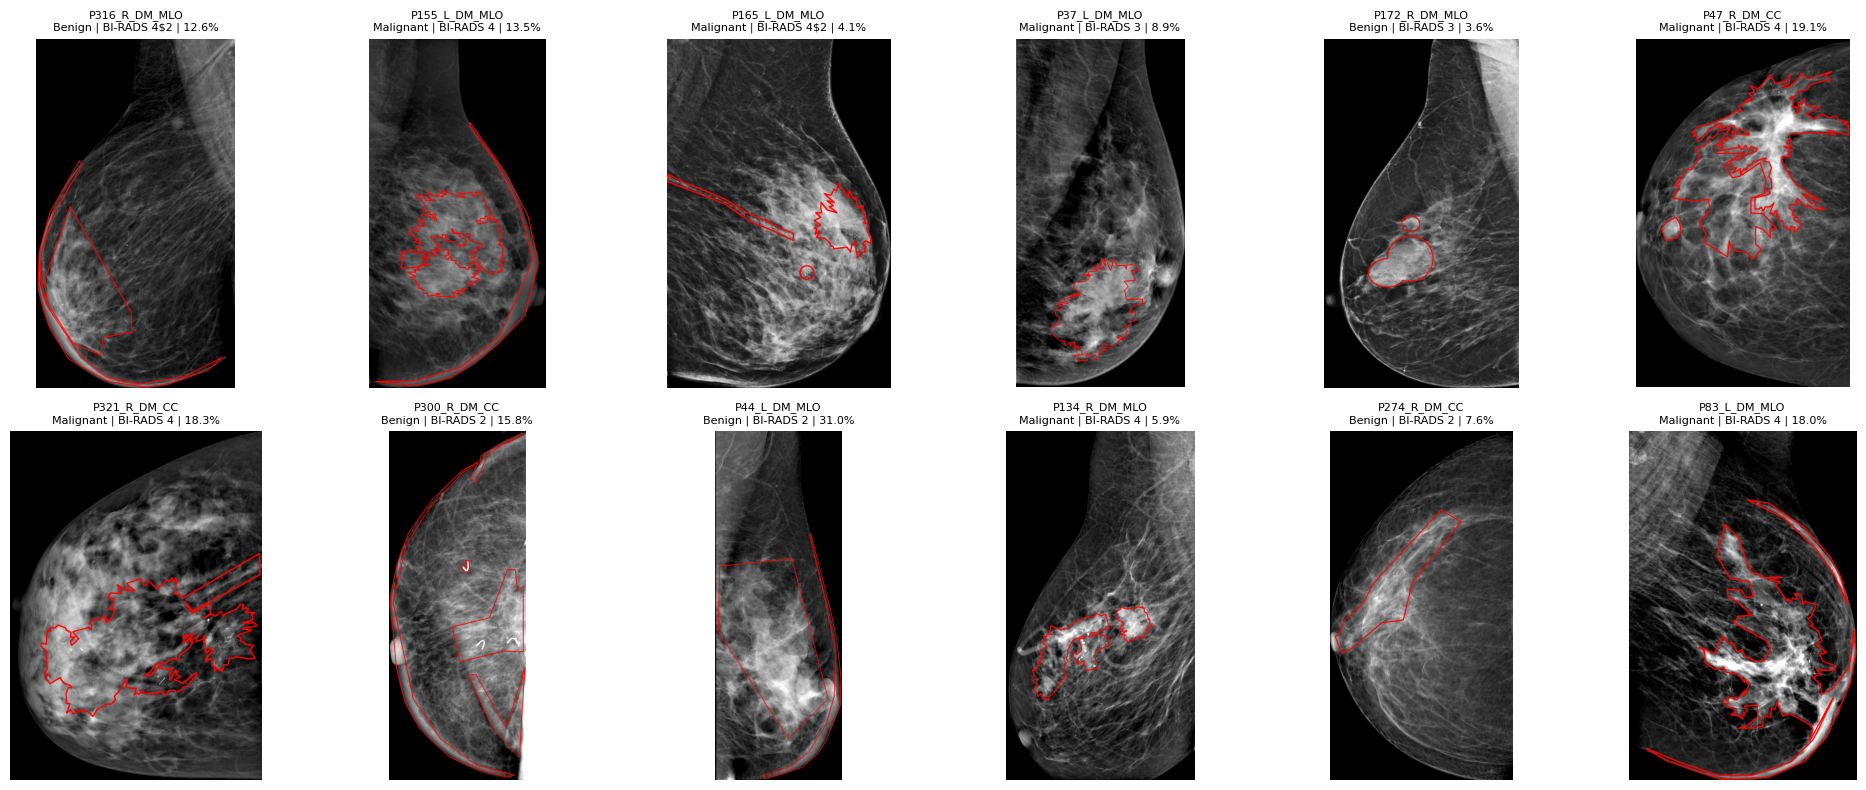

In [8]:
def overlay(img_path, mask_path, title):
    im = cv2.imread(img_path)
    m = cv2.imread(mask_path, 0)
    cs, _ = cv2.findContours((m > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(im, cs, -1, (0, 0, 255), max(3, im.shape[1] // 200))
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

roi = master[master.has_roi]
qc = roi.sample(min(N_QC_SAMPLES, len(roi)), random_state=SEED)
for _, r in qc.iterrows():
    cv2.imwrite(os.path.join(OUT_DIR, 'qc_overlays', f'{r.Image_name}_overlay.jpg'),
                cv2.cvtColor(overlay(r.image_path, r.mask_path, r.Image_name), cv2.COLOR_RGB2BGR))

show = qc.head(12)
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
for ax, (_, r) in zip(axes.ravel(), show.iterrows()):
    ax.imshow(overlay(r.image_path, r.mask_path, r.Image_name)); ax.axis('off')
    ax.set_title(f'{r.Image_name}\n{r.Label} | BI-RADS {r.BIRADS_raw} | {r.area_pct:.1f}%', fontsize=8)
for ax in axes.ravel()[len(show):]: ax.axis('off')
plt.tight_layout(); plt.show()

## 9. (Optional) Compare with previous masks

In [9]:
def dice(a, b):
    a, b = a > 0, b > 0
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else 2 * np.logical_and(a, b).sum() / s

if OLD_MASK_DIR and os.path.isdir(OLD_MASK_DIR):
    old = {norm_name(p).replace('_mask', ''): p for p in glob.glob(os.path.join(OLD_MASK_DIR, '*.png'))}
    comp = []
    for _, r in tqdm(master.iterrows(), total=len(master)):
        o = old.get(r.Image_name)
        mp = r.mask_path if isinstance(r.mask_path, str) else None
        if o is None and mp is None: continue
        new_m = cv2.imread(mp, 0) if mp else None
        old_m = cv2.imread(o, 0) if o else None
        if new_m is not None and old_m is not None and new_m.shape != old_m.shape:
            old_m = cv2.resize(old_m, new_m.shape[::-1], interpolation=cv2.INTER_NEAREST)
        d = dice(new_m, old_m) if (new_m is not None and old_m is not None) else np.nan
        comp.append(dict(Image_name=r.Image_name, Label=r.Label, in_old=o is not None,
                         in_new=bool(mp) and bool(r.has_roi), dice=d))
    comp = pd.DataFrame(comp)
    comp.to_csv(os.path.join(OUT_DIR, 'compare_old_masks.csv'), index=False)
    both = comp[comp.in_old & comp.in_new]
    print('Previous masks:', len(old), '| new masks with ROI:', int(master.has_roi.sum()), '| both:', len(both))
    print('Only in previous masks:', int((comp.in_old & ~comp.in_new).sum()),
          '| only in new masks:', int((~comp.in_old & comp.in_new).sum()))
    print(both.dice.describe().round(4).to_string())
    print('\nDice < 0.9 (needs checking):')
    print(both[both.dice < 0.9].sort_values('dice').head(20).to_string(index=False))
else:
    print('Previous-mask folder not set or not found — step skipped.')

Previous-mask folder not set or not found — step skipped.


## 10. Compress outputs

In [10]:
zip_base = os.path.join(os.path.dirname(OUT_DIR.rstrip('/')), 'masks_generated')
shutil.make_archive(zip_base, 'zip', OUT_DIR)
print('Zip:', zip_base + '.zip')
if IN_COLAB:
    from google.colab import files
    # files.download(zip_base + '.zip')   # uncomment to download directly to your computer

Zip: /content/drive/MyDrive/CDD-CESM/masks_generated.zip
